### Final Plan

For this project, I am implementing a two stage multi stage recommendation system, one stage being retrieval/candidate generation and the second stage being ranking. For the first stage retrieval, we are using multi-channel fusion with the four channels being TFIDF, ItemKNN, Alternating Least Squares, and Bayesian Personalized Ranking. For the retrieval stage we are using methods from the paper 'Unleashing the Potential of Multi-Channel Fusion in Retrieval for Personalized Recommendations' (Huang et al. 2024) and tuning budgets for each channel utilizing cross-entropy method outlined in the paper more detail in markdown cell. Then for the ranking stage we are using LightGBM with LambdaRank, using LambdaRank optimizes ranking.\
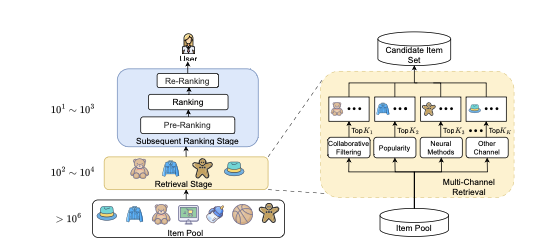\
^example of retreival architecture we are using from paper. 

### Get the Imports

In [38]:
import sys
import time
import warnings
from pathlib import Path
from collections import Counter, defaultdict
import lightgbm as lgb
from implicit.als import AlternatingLeastSquares
from implicit.bpr import BayesianPersonalizedRanking
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from itertools import product

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sys.path.append(str(Path(".").resolve()))
from evaluation_code import _recall_at_k, _ndcg_at_k, validate_submission, K as EVAL_K

In [2]:
# Reproducible configuration
# we set the hyper parameters at the top so we can easily tweak them if needed
# important thing to know is the factors that we are using which means that our laten vectors have 64 dimensions 
SEED= 42
DATA_DIR = Path("data")
CACHE_DIR = Path("cache"); CACHE_DIR.mkdir(exist_ok=True)
TOP_N_PER_CHANNEL = 500
PRERANK_TOP = 100
FINAL_TOP = 10
ALS_FACTORS, ALS_ITERATIONS, ALS_REG, ALS_ALPHA = 64, 15, 0.05, 5.0
BPR_FACTORS, BPR_ITERATIONS, BPR_LR = 64, 100, 0.01
NEG_PER_POS_LR = 20

HAS_IMPLICIT = True
HAS_LGB = True

np.random.seed(SEED)

## Data Loading

In [3]:
train = pd.read_csv("data/train.csv")
items = pd.read_csv("data/item_metadata.csv")
test_users = pd.read_csv("data/test_users.csv")

## Validation Split

So we know that the actual leaderboard ground truth is hiding the test users next five games that they're playing and our goal is to accurately predict these next five games. However, for local testing, we need to have a validation set up to mimic this split. We are given the unix timestamp of reviews that are made in the user-item interaction (train file) file so what we will be doing is holding out each users last five interactions and tried predicting these known five interactions to the best of our abilities as validation since we dont have ground truth.

In [4]:
sorted_train = train.sort_values(["user_id", "timestamp", "item_id"]).reset_index(drop=True) # so we sort by user then time stamp
sorted_train["rank_last_interaction"] = sorted_train.groupby("user_id").cumcount(ascending=False) # then we group by user id, then get the rank 0 as the last interaction and so on so forth

In [5]:
sorted_train

,user_id,item_id,playtime_minutes,timestamp,rank_last_interaction
0,u_00000,i_08250,660,1427612400,5
1,u_00000,i_20975,168,1427612400,4
2,u_00000,i_01923,606,1430809200,3
3,u_00000,i_27675,258,1456300800,2
4,u_00000,i_06792,54,1461481200,1
...,...,...,...,...,...
122361,u_09999,i_08645,0,1460358000,4
122362,u_09999,i_04220,444,1462345200,3
122363,u_09999,i_07062,30,1465974000,2
122364,u_09999,i_01739,288,1473490800,1


In [6]:
# from here we will account for the fact that tehre are some users that dont have even five interactions
# edge case handling
user_size = sorted_train.groupby("user_id")["user_id"].transform("size") # so we check user size
n_holdout = (user_size - 1).clip(upper=5) # assert that we can holdout up to 5 but always want to at least have one row for training
is_heldout = sorted_train["rank_last_interaction"] < n_holdout # we can use this to mask for our train and then val

In [7]:
val_train = sorted_train[~is_heldout]  # what our models will interact with
val_truth = sorted_train[is_heldout]  # the validation we will be using

In [8]:
val_train

,user_id,item_id,playtime_minutes,timestamp,rank_last_interaction
0,u_00000,i_08250,660,1427612400,5
6,u_00001,i_10930,2064,1482912000,6
7,u_00001,i_00428,288,1493276400,5
13,u_00002,i_02596,78,1390636800,4
18,u_00003,i_01111,1008,1397026800,13
...,...,...,...,...,...
122356,u_09999,i_05445,54,1449475200,9
122357,u_09999,i_11296,12,1449734400,8
122358,u_09999,i_10682,6,1453449600,7
122359,u_09999,i_02561,150,1454140800,6


In [9]:
val_truth

,user_id,item_id,playtime_minutes,timestamp,rank_last_interaction
1,u_00000,i_20975,168,1427612400,4
2,u_00000,i_01923,606,1430809200,3
3,u_00000,i_27675,258,1456300800,2
4,u_00000,i_06792,54,1461481200,1
5,u_00000,i_22342,540,1461481200,0
...,...,...,...,...,...
122361,u_09999,i_08645,0,1460358000,4
122362,u_09999,i_04220,444,1462345200,3
122363,u_09999,i_07062,30,1465974000,2
122364,u_09999,i_01739,288,1473490800,1


## Item Metadata Preprocessing
So we have three particular columns that tell us a lot of info about the game and its contents this bein the tags, genres, and specs columns. So for TF-IDf we want to have these three fields combine into one blob for each item. We also have a safeguard function to handle NAs and treat them as empty strings. 

In [10]:
def safe(s): # this is the safeguard that we implement quick one liner if block
    return "" if pd.isna(s) else str(s)

In [11]:
# using the .apply we can then apply this function to deal with NAs, add pipe operator between sections 
items["text_for_tfidf"] = (items["tags"].apply(safe) + " | " + items["genres"].apply(safe) + " | " + items["specs"].apply(safe))

In [12]:
# now we want to split into lists, with no pipe operator in between
def split_pipe(s):
    return [t.strip() for t in safe(s).split("|") if t.strip()]

In [13]:
items["tags_list"]   = items["tags"].apply(split_pipe) # we want the tags as a set not string, for later jaccard ebvaluation
items["genres_list"] = items["genres"].apply(split_pipe)

In [14]:
items.head(5)

,item_id,title,tags,genres,specs,developer,publisher,release_year,sentiment,text_for_tfidf,tags_list,genres_list
0,i_00000,Counter-Strike,Action|FPS|Multiplayer|Shooter|Classic|Team-Ba...,Action,Multi-player|Valve Anti-Cheat enabled,Valve,Valve,2000,Overwhelmingly Positive,Action|FPS|Multiplayer|Shooter|Classic|Team-Ba...,"[Action, FPS, Multiplayer, Shooter, Classic, T...",[Action]
1,i_00001,Rag Doll Kung Fu,Indie|Fighting|Multiplayer,Indie,Single-player|Multi-player,Mark Healey,Mark Healey,2005,Mixed,Indie|Fighting|Multiplayer | Indie | Single-pl...,"[Indie, Fighting, Multiplayer]",[Indie]
2,i_00002,Silo 2,Animation & Modeling|Software,Animation &amp; Modeling,NaN,Nevercenter Ltd. Co.,Nevercenter Ltd. Co.,2012,Mostly Positive,Animation & Modeling|Software | Animation &amp...,"[Animation & Modeling, Software]",[Animation &amp; Modeling]
3,i_00003,Call of Duty: World at War,Zombies|World War II|FPS|Action|Multiplayer|Sh...,Action,Single-player|Multi-player|Co-op,Treyarch,Activision,2008,Very Positive,Zombies|World War II|FPS|Action|Multiplayer|Sh...,"[Zombies, World War II, FPS, Action, Multiplay...",[Action]
4,i_00004,3D-Coat V4.8,Animation & Modeling,Animation &amp; Modeling,Steam Cloud,Pilgway,Pilgway,2012,Very Positive,Animation & Modeling | Animation &amp; Modelin...,[Animation & Modeling],[Animation &amp; Modeling]


In [15]:
item_tag_set = dict(zip(items["item_id"], items["tags_list"].apply(set)))
item_genre_set = dict(zip(items["item_id"], items["genres_list"].apply(set)))
item_dev = dict(zip(items["item_id"], items["developer"].fillna("")))
item_pub = dict(zip(items["item_id"], items["publisher"].fillna("")))
item_year = dict(zip(items["item_id"], items["release_year"]))
# lookup tables for feature engineering

In [16]:
item_ids_catalog = items["item_id"].values
item_id_to_index = {iid: i for i, iid in enumerate(item_ids_catalog)}
n_items_catalog = len(item_ids_catalog)

## Constructing Channels 
Channel 1: TF-IDF\
Channel 2: Matrix Factorization ALS \
Channel 3: Bayesian Personalized Ranking\
Channel 4: ItemKnn

### Channel 1 TF-IDF
TF-IDF stands for term frequency and inverse document frequency, goal to turn text documment into vectors where dimesnions are the words and the values tell us how informativea particular word is for a particular document.

In [17]:
# initialize tfidf vector object
tfidf_vec = TfidfVectorizer(
    token_pattern=r"[^|\s]+", # nanything that isnt | or white space regex
    lowercase=True, 
    min_df=5, # ig/nore any tags that appear in less than 5 items this is noise
    max_df=0.5, # any tags that appear in more than half of the items doesn't really tell us much
    sublinear_tf=True, # 1 + log(tf)
    norm="l2", # normalize each row to unit length
)

In [18]:
item_tfidf = tfidf_vec.fit_transform(items["text_for_tfidf"]) # fit transform onto items

In [19]:
def build_user_tfidf_profile(history_item_ids):
    """
    Building users taste profile by averaging TF-IDF vectors of items they interacted with
    """
    index = [] # list of item IDS user has interacted with
    for i in history_item_ids: 
        # iterate through each item ID in user history, lookup in item_id_to_index dict
        if i in item_id_to_index:
            index.append(item_id_to_index[i])
    if not index: # if none of user items found in cataglog return NOne
        return None
    
    return np.asarray(item_tfidf[index].mean(axis=0)) #return average content prefernce of user

def tfidf_retrieve(history_item_ids, top_n=TOP_N_PER_CHANNEL):
    """
    Retreival stage given the users history we return the top N most content similar items
    history_oitem_ids is the users history and the top_n tells us how many candidates to return
    """
    u = build_user_tfidf_profile(history_item_ids) # build users average TF-IDF profile vector 
    if u is None:
        return []
    scores = (item_tfidf @ u.T).ravel() # scoring step where we multiply each items TF-iDF vector with users profile vector, dot profuctsimilarity, not cosine similarity
    for item_id in history_item_ids: # cycle thtough each item
        if item_id in item_id_to_index: # if item has already been seen by user mask item user has seen 
            scores[item_id_to_index[item_id]] = -np.inf

    top_index = np.argpartition(-scores, min(top_n, len(scores)-1))[:top_n] # get top N positions in O(n) using argpartition fast partial sort
    top_index = top_index[np.argsort(-scores[top_index])] # sort in descending for top N positions
    return [(item_ids_catalog[i], float(scores[i])) for i in top_index if np.isfinite(scores[i])] #build outpit list of item id score tuples

### Channel 2 ALS
We are using matrix factorization which is conceptually when we factor the user-item utilty matrix $S$ into $U * V^T$ where U holds the user vectors and V holds the item vectors the dot product of the two is what is predicting the rating. We are using ALS to having the V being fixed and treating U to be a closed form least squares problem. SO we alternate fix V solve for U then fix U and solve for V and so on so forth. We don't have ratings and only ratings so we use a confidence weighted version from "Collaborative Filtering for Implicit Feedback Datasets" by Hu et al. and use the following equation `conf = 1.0 + alpha * np.log1p(playtime)` where the key intuition is that the longer playtime the more confident we are the user likes it. 

In [20]:
def train_als(train, factors=ALS_FACTORS, iterations=ALS_ITERATIONS, regularization=ALS_REG, alpha=ALS_ALPHA, seed=SEED):
    user_ids = train["user_id"].unique() # get unique users in interaction set
    user_id_to_index = {u: i for i, u in enumerate(user_ids)} # build lookup for user id to raw index
     # convert each interaction row into row index and column index coordinates for matrix
    rows = train["user_id"].map(user_id_to_index).values
    cols = train["item_id"].map(item_id_to_index).values

    conf = 1.0 + alpha * np.log1p(train["playtime_minutes"].values) # compute confidence weights from Hu et. al
    mat = csr_matrix((conf, (rows, cols)), shape=(len(user_ids), n_items_catalog)) # build the user item confidence matrix, shape is n_users by n_itemcatalog

    als_model = AlternatingLeastSquares(factors=factors, regularization=regularization, iterations=iterations, use_gpu=False, random_state=seed) # create ALS instance
    als_model.fit(mat, show_progress=False) # fit

    return {"user_id_to_index": user_id_to_index, "user_factors": np.asarray(als_model.user_factors), # return a dictionary of everything we need
            "item_factors": np.asarray(als_model.item_factors),
            "matrix": mat}

def als_retrieve(als, user_id, history_item_ids, top_n=TOP_N_PER_CHANNEL):
    """
    Retreival stage given the users history we return the top N candidates, except using trained ALS fators to score each item 
    Very similar process, collaborative similarity not content similarity 
    """
    if user_id not in als["user_id_to_index"]:
        return []
    user_index = als["user_id_to_index"][user_id]
    scores = als["item_factors"] @ als["user_factors"][user_index]
    for item_id in history_item_ids:
        if item_id in item_id_to_index:
            scores[item_id_to_index[item_id]] = -np.inf
    top_index = np.argpartition(-scores, min(top_n, len(scores)-1))[:top_n]
    top_index = top_index[np.argsort(-scores[top_index])]
    return [(item_ids_catalog[i], float(scores[i])) for i in top_index if np.isfinite(scores[i])]


In [21]:
als_val  = train_als(val_train)
als_full = train_als(train)

### Channel 3 BPR
BPR is also a type of matrix factorization but is optimized for a different objective. Basically for every positive observation where we have a user item pair we pick a negative item j which user u has not seen and maximize for the triple (u, i, j) where i is our positive observed and j is sampled negative. 
We look for the score gap which is how much more the model prefers i over j for user u
mathematically written as...\
$x_{uij} = u^Tv_i − u^Tv_j$\
We then take this gap and look at it as a probability from 0 to 1 by mapping it into the sigmoid function written $\sigma(x_{uij})$. We want this probability to be as close to 1 for every obvserved against unobserved pair sothis objective.summed over all sampled triples is. 
$$
\max \sum \log \sigma(\mathbf{u}^T \mathbf{v}_i - \mathbf{u}^T \mathbf{v}_j) - \lambda (\|\mathbf{U}\|^2 + \|\mathbf{V}\|^2)
$$
Typical to other machine learning framings of optimization we solve this using SGD which is why we must consider iterations and learning rate for updates to each vector. Where $u$ is the latent feature vector  for user u, $v_i$ is the latent feature vector for the positive item i and $v_j$ is the latent feature vector for the negative item j. The goal directions of the SGD is to increase the score for the positive pair $\mathbf{u}^T \mathbf{v}_i$ and decrease the score of negative pair $\mathbf{u}^T \mathbf{v}_j$. 

In [22]:
def train_bpr(train, factors=BPR_FACTORS, iterations=BPR_ITERATIONS, learning_rate=BPR_LR, seed=SEED):
    user_ids = train["user_id"].unique() # get unique users in interaction set
    user_id_to_index = {u: i for i, u in enumerate(user_ids)} # build lookup for user id to raw index
    # convert each interaction row into row index and column index coordinates for matrix
    rows = train["user_id"].map(user_id_to_index).values
    cols = train["item_id"].map(item_id_to_index).values

    mat = csr_matrix((np.ones(len(rows), dtype=np.float32), (rows, cols)), shape=(len(user_ids), n_items_catalog)) # build binary user item interaction matrix, BPR only cares about observed vs unobserved

    bpr_model = BayesianPersonalizedRanking(factors=factors, learning_rate=learning_rate, iterations=iterations, use_gpu=False, random_state=seed) # create BPR instance
    bpr_model.fit(mat, show_progress=False) # fit

    return {"user_id_to_index": user_id_to_index, "user_factors": np.asarray(bpr_model.user_factors), # return a dictionary of everything we need
            "item_factors": np.asarray(bpr_model.item_factors),
            "matrix": mat}

#BPR has same return dictionary shape so retrieve function can be shared
def bpr_retrieve(bpr, user_id, history_item_ids, top_n=TOP_N_PER_CHANNEL):
    return als_retrieve(bpr, user_id, history_item_ids, top_n)

In [23]:
bpr_val  = train_bpr(val_train)
bpr_full = train_bpr(train)

### Channel 4 ItemKNN
Basically item based collaborative filterng where we are lookng for users who played some item i also played item j.

In [24]:
def build_itemknn(train):
    user_ids = train["user_id"].unique() # grab uwer ids 
    user_id_to_index = {u: i for i, u in enumerate(user_ids)} # build lookup

    # convert each interaction row into row index and column index coordinates for matrix
    rows = train["user_id"].map(user_id_to_index).values
    cols = train["item_id"].map(item_id_to_index).values
    # do log1p transform for heavy tail
    data = np.log1p(train["playtime_minutes"].values)

    # build the matrix
    user_item = csr_matrix((data, (rows, cols)), shape=(len(user_ids), n_items_catalog))

    # transpose to get the item use rmatrics row is an item and row vector is items interactions across users 
    # have csc natrix bc we transposed a csr, we recast back to csr so faster
    return normalize(user_item.T.tocsr(), norm="l2", axis=1) # l2 normalize eahch row

def itemknn_retrieve(history_item_ids, item_vecs, top_n=TOP_N_PER_CHANNEL):
    hist_index = [item_id_to_index[i] for i in history_item_ids if i in item_id_to_index] # map user history item ids to row indices in item_vecs

    if not hist_index: #user with no history
        return []

    pooled = item_vecs[hist_index].sum(axis=0).T #pool user history into single vector by summing over teh rows of the items they interacted with
    scores = np.asarray(item_vecs @ pooled).ravel() # cosine similarity of every catalog item against the pooled history vector

    for item_id in history_item_ids: #mask out already seen items
            scores[item_id_to_index[item_id]] = -np.inf

    top_index = np.argpartition(-scores, min(top_n, len(scores)-1))[:top_n] # get top N positions in O(n) using argpartition fast partial sort
    top_index = top_index[np.argsort(-scores[top_index])] # sort in descending for top N positions

    return [(item_ids_catalog[i], float(scores[i])) for i in top_index if np.isfinite(scores[i])] # map indexes back to the raw item ids and drop any -inf that slipped through


In [25]:
itemknn_val  = build_itemknn(val_train)
itemknn_full = build_itemknn(train)

# Candidate Pool and CEM Tuned Channel Weights
As of now we have four outlined retrieval channels, and each one given a user can give us a ranked list of hundreds of candidate items that we can use. But our later ranker can only rank on a certain number of candidates, this is the pool that we want to rank out of. So we want to know in the total slots that we have for each candidate's retreived pool how many slots in this pool should each of the 4 channel contribute to! The goal here is that for each user we run all four channels with their allocated per channel budget then we union the results. 
Methematically outlined as: 
if channel k has weight k and total pool size is L then channel k contributes its top rounded(w_k * L) items to the pool 
We union these items across all 4 channels and the final candidate pool of size less than or equal to L which depends if there is overlap between the top items from each channel.
\
So we want to find weights which sum to 1 that allocate budgets that maximize Recall on validation. 

We use the Cross Entropy Method outlined in the paper which works as follows...
1. Maintain a Dirichlet distribution over weight vectors.
2. Sample Q candidate weight vectors from it.
3. Evaluate each (compute pool recall).
4. Keep top q% ("elite samples").
5. Update Dirichlet params to be more concentrated near the elites.
6. Repeat until convergence.

### Build Candidate Pool

In [26]:
def build_candidate_pool(user_histories, als, bpr, itemknn, top_n_per_channel=TOP_N_PER_CHANNEL, channel_budgets=None):
    """
    Four-channel union TF-IDF + ItemKNN + ALS-U2I + BPR-U2I.
    channel_budgets : dict with keys {"tfidf", "itemknn", "als", "bpr"}.
    """
    # user histories is our dictionary of user ids and their historical item interaction item ids
    # take in als, bpr model dictionaries, itemknn sparse matric, default fall back per channel budget
    
    # default fallback
    if channel_budgets is None: 
        channel_budgets = {"tfidf":top_n_per_channel, "itemknn":top_n_per_channel, "als":top_n_per_channel, "bpr":top_n_per_channel}
    
    
    rows = [] # accumulator for output df each row is user, item, scores
    for i, (user_id, history) in enumerate(user_histories.items()): # loop over each user
        per_item = {} #scratch dictionary where key is itemid union channel results for users, if multiple channels get same item we just add same score to inner dictionary so no duplication

        # for all channels we assure budget is above 0 or we skip!
        if channel_budgets["tfidf"] > 0: 
            for item_id, score in tfidf_retrieve(history, channel_budgets["tfidf"]): # for each pair..
                per_item.setdefault(item_id, {})["score_tfidf"] = score # if item hasnt been seen yet initialize inner dcictionary, else return existing dictionary
                #then stash score under item key in dictionary.
        if channel_budgets["itemknn"] > 0:
            for item_id, score in itemknn_retrieve(history, itemknn, channel_budgets["itemknn"]):
                per_item.setdefault(item_id, {})["score_itemknn"] = score
        if channel_budgets["als"] > 0:
            for item_id, score in als_retrieve(als, user_id, history, channel_budgets["als"]):
                per_item.setdefault(item_id, {})["score_als"] = score
        if channel_budgets["bpr"] > 0:
            for item_id, score in bpr_retrieve(bpr, user_id, history, channel_budgets["bpr"]):
                per_item.setdefault(item_id, {})["score_bpr"] = score

        for item_id, scores_dict in per_item.items(): # have a structure where "item_42": {"s_tfidf": 0.81, "s_als": 1.23, "s_bpr": 0.55},
            rows.append({ # walk through every candidate item for user and flatten to row in data frame
                "user_id": user_id,
                "item_id": item_id,
                "s_tfidf":   scores_dict.get("score_tfidf",0.0),
                "s_itemknn": scores_dict.get("score_itemknn",0.0),
                "s_als":     scores_dict.get("score_als",0.0),
                "s_bpr":     scores_dict.get("score_bpr",0.0),
                "n_channels": len(scores_dict),
            })
        if (i + 1) % 1000 == 0:
            print(f"  built pool for {i+1:,} / {len(user_histories):,} users")
    return pd.DataFrame(rows)

In [27]:
val_histories = val_train.groupby("user_id")["item_id"].apply(list).to_dict()


### CEM Tuned Channel Weights
The first method paper describes is Cross Entropy Method a stochastic optimization technique,w chich iteratively will update weights to get weights for each channel that sum to 1. To make syre teh channel weights sum to one we use the Dirichlet Distribution for the weight vector. FOr each weight vector we compute retrieval performance, after evaluating all samples we rank them in descending order and slect the top some q percent as the elite set.


In [28]:
# Config
L_TOTAL = 400 # total candidate pool size we want for each usser, channel budget shold never exceed this
PRECOMPUTE_DEPTH = L_TOTAL # never need more than total candidate pool sizer from any channel so this is why we set this parameter!

In [29]:
channel_lists = {} # this will be a nested dictionary with the following setup {user_id: {channel_name: [ranked_item_ids]}}

for user_id, history in val_histories.items(): # iterate through histories
    channel_lists[user_id] = { # for each validation user run each of the 4 channels once retrieve 400 candidates in perspective of that channel
        "tfidf":   [item_id for item_id, _ in tfidf_retrieve(history, PRECOMPUTE_DEPTH)],
        "itemknn": [item_id for item_id, _ in itemknn_retrieve(history, itemknn_val, PRECOMPUTE_DEPTH)],
        "als":     [item_id for item_id, _ in als_retrieve(als_val, user_id, history, PRECOMPUTE_DEPTH)],
        "bpr":     [item_id for item_id, _ in bpr_retrieve(bpr_val, user_id, history, PRECOMPUTE_DEPTH)],
    }

In [30]:
pd.DataFrame(channel_lists) # clearer view of whats going on

,u_00000,u_00001,u_00002,u_00003,u_00004,u_00005,u_00006,u_00007,u_00008,u_00009,...,u_09990,u_09991,u_09992,u_09993,u_09994,u_09995,u_09996,u_09997,u_09998,u_09999
tfidf,"[i_05554, i_01118, i_08055, i_06036, i_12722, ...","[i_02229, i_00763, i_06783, i_13674, i_00023, ...","[i_05180, i_01523, i_02786, i_08396, i_05976, ...","[i_02317, i_01645, i_08754, i_05439, i_03468, ...","[i_03863, i_08962, i_00161, i_15736, i_06453, ...","[i_05439, i_00027, i_01810, i_10695, i_02328, ...","[i_18681, i_05516, i_11365, i_18078, i_05439, ...","[i_02321, i_02631, i_14458, i_03490, i_18343, ...","[i_09976, i_10120, i_26522, i_04288, i_14082, ...","[i_14741, i_12951, i_17181, i_20820, i_27377, ...",...,"[i_00129, i_05976, i_04672, i_04524, i_07429, ...","[i_00468, i_31903, i_01733, i_00011, i_17923, ...","[i_01284, i_06331, i_05296, i_12424, i_04341, ...","[i_02614, i_02896, i_03398, i_16836, i_03357, ...","[i_18682, i_02767, i_23245, i_22749, i_05673, ...","[i_04603, i_02741, i_02736, i_09070, i_14713, ...","[i_24642, i_02300, i_24146, i_14639, i_01285, ...","[i_28593, i_07370, i_02280, i_00205, i_00489, ...","[i_04672, i_03151, i_01201, i_07266, i_00129, ...","[i_08082, i_19547, i_05168, i_24642, i_07181, ..."
itemknn,"[i_08758, i_18749, i_10900, i_12211, i_16881, ...","[i_01044, i_03773, i_14808, i_12772, i_09509, ...","[i_25829, i_20245, i_07104, i_12630, i_02786, ...","[i_14604, i_11373, i_01480, i_03773, i_01486, ...","[i_21492, i_10252, i_15111, i_26538, i_17546, ...","[i_11910, i_14115, i_18863, i_10316, i_16426, ...","[i_03773, i_10316, i_01937, i_01523, i_00062, ...","[i_21139, i_16091, i_11785, i_08936, i_10436, ...","[i_10691, i_09613, i_08936, i_11785, i_21139, ...","[i_15852, i_15552, i_06212, i_28108, i_06390, ...",...,"[i_11409, i_08222, i_10243, i_01472, i_03795, ...","[i_01480, i_24980, i_17626, i_01486, i_00122, ...","[i_30914, i_24696, i_08617, i_12379, i_19469, ...","[i_17859, i_05684, i_13840, i_02842, i_05438, ...","[i_03228, i_01208, i_03302, i_09509, i_00767, ...","[i_02509, i_04603, i_10549, i_14802, i_06518, ...","[i_10984, i_12722, i_09535, i_07014, i_13689, ...","[i_09260, i_08222, i_01472, i_03795, i_07004, ...","[i_14604, i_00377, i_06805, i_24696, i_12379, ...","[i_01486, i_16877, i_00122, i_21094, i_08518, ..."
als,"[i_06450, i_02470, i_01451, i_03865, i_02331, ...","[i_00126, i_00057, i_00249, i_14604, i_00395, ...","[i_01468, i_02334, i_00126, i_01923, i_02299, ...","[i_04580, i_02105, i_01480, i_01808, i_01486, ...","[i_02676, i_02105, i_00440, i_11355, i_01746, ...","[i_11910, i_00724, i_05786, i_09124, i_06397, ...","[i_00062, i_01746, i_01937, i_01480, i_05472, ...","[i_01129, i_02318, i_01135, i_04602, i_03194, ...","[i_02507, i_01545, i_01135, i_03495, i_17626, ...","[i_04580, i_28547, i_01334, i_01545, i_00377, ...",...,"[i_02282, i_00037, i_02409, i_05267, i_00428, ...","[i_24980, i_01480, i_05188, i_00922, i_00054, ...","[i_01468, i_08052, i_01523, i_02235, i_14604, ...","[i_01403, i_02136, i_01537, i_07728, i_05337, ...","[i_24980, i_01490, i_00470, i_24302, i_00767, ...","[i_04603, i_00724, i_17626, i_05103, i_01539, ...","[i_25690, i_01535, i_00037, i_01486, i_12430, ...","[i_00389, i_01202, i_02280, i_28982, i_02282, ...","[i_14604, i_01798, i_00037, i_21094, i_02683, ...","[i_01129, i_02236, i_21094, i_13084, i_11355, ..."
bpr,"[i_05300, i_05854, i_02269, i_02778, i_06704, ...","[i_01850, i_00249, i_01044, i_02409, i_02314, ...","[i_01732, i_02472, i_03136, i_02282, i_05300, ...","[i_00126, i_13651, i_00717, i_00313, i_00468, ...","[i_05300, i_03136, i_11369, i_03651, i_02778, ...","[i_05167, i_01201, i_09345, i_01937, i_05976, ...","[i_01998, i_10930, i_03819, i_01334, i_02229, ...","[i_02314, i_06704, i_05854, i_01443, i_02269, ...","[i_04221, i_01993, i_03319, i_02634, i_02317, ...","[i_05300, i_02697, i_03651, i_03136, i_02025, ...",...,"[i_02472, i_00073, i_01732, i_02707, i_03334, ...","[i_10518, i_17924, i_00077, i_01746, i_01480, ...","[i_02596, i_00073, i_05857, i_05653, i_00062, ...","

In [31]:
val_truth_dict_cem = val_truth.groupby("user_id")["item_id"].apply(set).to_dict() # build the validation lookup dictionary where key is user_id and holds each users set of held out recent items they have interacted with
CHANNEL_ORDER = ["tfidf", "itemknn", "als", "bpr"] #order to match what we have above^

def budgets_from_weights(weights, L=L_TOTAL):
    budgets = [] # budgets initialzied
    for weight in weights: # for weight in the weight vector
        budgets.append(int(round(weight * L))) # get discrete item amount we will take from each channel
    diff = L - sum(budgets) # see difference between our goal candidate pool size and what we have
    if diff != 0: # if there is adifference
        budgets[int(np.argmax(weights))] += diff # round up or down for each to get it to around 400~
    return budgets

def eval_weights(weights):
    """
    Take weight vector and return average per user recall
    """
    budgets = budgets_from_weights(weights)
    recalls = [] # accumulates per-user values for averaging
    for user_id, truth in val_truth_dict_cem.items(): # user id and ground truth item pairs
        if not truth: # skip anyone with no held out interacted with items
            continue

        lists = channel_lists.get(user_id, {}) # grab precomputed channel rankings 
        
        pool = set() # initialize a set, so we can get only the union of candidates across all channelss
        
        for channel, budget in zip(CHANNEL_ORDER, budgets): # for each channel in our predetermined ordder
            pool.update(lists.get(channel, [])[:budget]) # take the top allocated budget items for each channel and add to the pool!
        recalls.append(len(truth & pool) / len(truth)) # get the recall
    return float(np.mean(recalls))  # return mean recall across all users

In [32]:
baseline_recall = eval_weights(np.array([1/4]*4)) # get baseline recall with initialized equal weightage

In [33]:
baseline_recall # this is the recall we want to beat

0.35515166666666664

In [34]:
alpha = np.ones(4) # initialize the dirichlet distribution, 'with the concentration parameter 𝜶 = [𝛼1,𝛼2,...,𝛼𝐾]^⊤'
# as the paper states all ones in the distribution means its uniform over simplex which means every weright vector is equally likely
Q, q_elite, eta1, n_iters, patience = 50, 0.2, 0.5, 15, 4 # initialize all our CEM hyperparameter hyperparameters 
# Q = 50, we are sampling 50 weight vectors per iteration
# q_elite = 0.2 taking top 20% as the elite set
# sset learning rate to 0.5 
# take 15 iterations for weight update 
# implement early stopping after 4 iterations if no weight updates for 4 iterations in a row
best_score, best_alpha, patience_ct = -np.inf, alpha.copy(), 0 # track best score, best alpha and iteration count
cem_rng = np.random.default_rng(SEED) # set seed

In [35]:
print(f"\nRunning CEM (Q={Q}, elite={q_elite}, eta={eta1})...")
for iteration in range(n_iters): # for iterations we have
    samples = cem_rng.dirichlet(alpha, size=Q) # get Q candidate weightvectors from current dirichlet
    scores  = np.array([eval_weights(weights) for weights in samples]) # score each samples weight vector by getting poo recall 

    n_elite = max(1, int(q_elite * Q)) # get the amount we want for elite selection
    elite = samples[np.argsort(-scores)[:n_elite]] # slice that much off

    elite_mean = elite.mean(axis=0) # per channel everage weight across elite
    elite_var = elite.var(axis=0).mean() #variance across 4 components
    scale = max((elite_mean[0] * (1 - elite_mean[0]) / max(elite_var, 1e-6)) - 1, 1.0) # beta dist with mu and sig^2 var. adapt to find how concentrated new Dirichlet should be based on how tight the elites are clustered
    alpha = (1 - eta1) * alpha + eta1 * elite_mean * scale # CEM update

    iter_best = scores.max() # log per iteration progress update
    print(f" iter {iteration:2d}: mean={scores.mean():.4f}  best={iter_best:.4f}  "
          f"alpha=[tfidf={alpha[0]:.2f}, itemknn={alpha[1]:.2f}, als={alpha[2]:.2f}, bpr={alpha[3]:.2f}]") # iteration updates
    if iter_best > best_score + 1e-5: # if best beat global best by margin
        best_score, best_alpha, patience_ct = iter_best, alpha.copy(), 0 #store values
    else:
        patience_ct += 1 #early stopping
        if patience_ct >= patience:
            print(f"  early stop after {iteration+1} iters"); break



Running CEM (Q=50, elite=0.2, eta=0.5)...
 iter  0: mean=0.3508  best=0.3749  alpha=[tfidf=0.60, itemknn=0.90, als=1.12, bpr=0.65]
 iter  1: mean=0.3550  best=0.3741  alpha=[tfidf=0.36, itemknn=0.73, als=1.47, bpr=0.41]
 iter  2: mean=0.3634  best=0.3734  alpha=[tfidf=0.37, itemknn=0.66, als=2.89, bpr=0.60]
 iter  3: mean=0.3690  best=0.3743  alpha=[tfidf=0.51, itemknn=0.83, als=6.13, bpr=0.85]
 iter  4: mean=0.3715  best=0.3755  alpha=[tfidf=0.75, itemknn=1.31, als=9.43, bpr=1.38]
 iter  5: mean=0.3718  best=0.3749  alpha=[tfidf=2.03, itemknn=2.25, als=18.86, bpr=2.98]
 iter  6: mean=0.3729  best=0.3752  alpha=[tfidf=4.12, itemknn=3.56, als=37.21, bpr=6.27]
 iter  7: mean=0.3735  best=0.3752  alpha=[tfidf=6.59, itemknn=5.79, als=65.49, bpr=12.95]
 iter  8: mean=0.3741  best=0.3754  alpha=[tfidf=11.82, itemknn=9.15, als=114.80, bpr=24.90]
  early stop after 9 iters


In [36]:
# fnalizes CEM result

weights_cem = best_alpha / best_alpha.sum() # convert dirichlet parameters into single weight vector
budgets_cem= budgets_from_weights(weights_cem) # turn cont. weights into integer slot counts
final_recall= eval_weights(weights_cem) # validation recall
CEM_BUDGETS= {channel: budget for channel, budget in zip(CHANNEL_ORDER, budgets_cem)} # comvert budgets lists into dictionary format


In [39]:
print(f"\n CEM weights (L={L_TOTAL}):")
for channel, weight, budget in zip(CHANNEL_ORDER, weights_cem, budgets_cem):
    print(f"{channel:8s}: w={weight:.3f}  budget={budget}")
print(f"  Recall@{L_TOTAL}: {baseline_recall:.4f} (equal) → {final_recall:.4f} (CEM)  ({(final_recall-baseline_recall)/baseline_recall*100:+.1f}%)")

print(f"\nBuilding val_pool...")
start_time = time.time()
val_pool = build_candidate_pool(val_histories, als_val, bpr_val, itemknn_val, channel_budgets=CEM_BUDGETS)
print(f"  done in {time.time()-start_time:.1f}s. Pool: {len(val_pool):,} rows ({len(val_pool)/len(val_histories):.1f}/user)")



 CEM weights (L=400):
tfidf   : w=0.058  budget=23
itemknn : w=0.102  budget=41
als     : w=0.732  budget=293
bpr     : w=0.107  budget=43
  Recall@400: 0.3552 (equal) → 0.3740 (CEM)  (+5.3%)

Building val_pool...
  built pool for 1,000 / 10,000 users
  built pool for 2,000 / 10,000 users
  built pool for 3,000 / 10,000 users
  built pool for 4,000 / 10,000 users
  built pool for 5,000 / 10,000 users
  built pool for 6,000 / 10,000 users
  built pool for 7,000 / 10,000 users
  built pool for 8,000 / 10,000 users
  built pool for 9,000 / 10,000 users
  built pool for 10,000 / 10,000 users
  done in 24.6s. Pool: 3,601,037 rows (360.1/user)


### Retrieval Recall @ K

In [40]:
val_truth_dict = val_truth.groupby("user_id")["item_id"].apply(set).to_dict()
pool_by_user = val_pool.groupby("user_id")["item_id"].apply(set).to_dict()

recalls = []
for uid, truth in val_truth_dict.items():
    pool = pool_by_user.get(uid, set())
    hits = len(truth & pool)
    recalls.append(hits / len(truth))

In [41]:
print(f"Retrieval Recall@ ~{int(val_pool.groupby('user_id').size().mean())} (averag pool size per user):")
print(f"mean recall : {np.mean(recalls):.4f}")
print(f"median recall: {np.median(recalls):.4f}")
print(f"users with recall=0: {sum(r == 0 for r in recalls):,} / {len(recalls):,}")
print(f"users with recall=1: {sum(r == 1 for r in recalls):,} / {len(recalls):,}")

Retrieval Recall@ ~360 (averag pool size per user):
mean recall : 0.3740
median recall: 0.4000
users with recall=0: 2,131 / 10,000
users with recall=1: 489 / 10,000


# Feature Engineering for Stage 2

In [42]:
def compute_user_features(train_df):
    """
    Per user feature table, one row per user has summary statistics on
    """
    df = train_df.copy() # create copy of the train df
    df["day"] = pd.to_datetime(df["timestamp"], unit="s").dt.normalize() # covert uniz timestamp
    user_feats = df.groupby("user_id").agg( # aggregate by user summary stats
        user_history_size= ("item_id", "count"),
        user_total_playtime =("playtime_minutes", "sum"),
        user_mean_playtime= ("playtime_minutes", "mean"),
        user_days_active =("day", lambda s: (s.max() - s.min()).days + 1),
    ).reset_index()
    user_feats["user_total_playtime"] = np.log1p(user_feats["user_total_playtime"]) # do log 1p on playtime to get rid of heavy tail
    user_feats["user_mean_playtime"]  = np.log1p(user_feats["user_mean_playtime"])  # do log 1p on playtime to get ready of heavy tail

    # get distinct tags in user's history
    def n_unique_tags(items_played):
        tags = set() # initialize a set to get rid of duplicates
        for item_id in items_played: # for each item in the historical items played, look at the tags attached to item
            tags.update(item_tag_set.get(item_id, [])) #union theseand get what unique tags each user likes 
        return len(tags) # size tells us how broad the taste is
    
    tags_per_user = df.groupby("user_id")["item_id"].apply(n_unique_tags).rename("user_unique_tags") # group by user take list of item IDs and apply heloer func to get count of unique tags
    user_feats = user_feats.merge(tags_per_user, on="user_id")
    return user_feats # return the user features!


In [43]:
user_feats_val = compute_user_features(val_train)
user_feats_val.head()

,user_id,user_history_size,user_total_playtime,user_mean_playtime,user_days_active,user_unique_tags
0,u_00000,1,6.493754,6.493754,1,10
1,u_00001,2,7.763446,7.070724,121,32
2,u_00002,1,4.369448,4.369448,1,20
3,u_00003,9,9.640758,7.444054,97,79
4,u_00004,1,0.000000,0.000000,1,10


In [44]:
user_feats_val.describe()

,user_history_size,user_total_playtime,user_mean_playtime,user_days_active,user_unique_tags
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,8.108700,8.166343,7.075557,299.190200,48.342400
std,18.126763,2.253052,1.649619,482.088581,43.237675
min,1.000000,0.000000,0.000000,1.000000,1.000000
25%,1.000000,6.675823,6.163315,1.000000,20.000000
50%,2.000000,8.294799,7.136165,1.000000,25.000000
75%,8.000000,9.828710,8.119994,444.000000,68.000000
max,531.000000,14.995622,13.357782,2585.000000,308.000000


In [45]:
SENTIMENT_ORDINAL = {
    "Overwhelmingly Negative": -4, "Very Negative": -3, "Mostly Negative": -2, "Negative": -1,
    "Mixed": 0,
    "Positive": 1, "Mostly Positive": 2, "Very Positive": 3, "Overwhelmingly Positive": 4,
} # give ordinal encoding to each review sentiment so we are basically turning the categorical feature into a numerical feature 

def compute_item_features(train_df):
    popularity = train_df.groupby("item_id").agg( # aggregate popularity state for each item
        item_popularity = ("user_id", "count"),
        item_mean_playtime = ("playtime_minutes", "mean"),
    ).reset_index()

    popularity["item_popularity"] = np.log1p(popularity["item_popularity"]) # log1p transform for tail
    popularity["item_mean_playtime"] = np.log1p(popularity["item_mean_playtime"].fillna(0))

    item_features = items[["item_id", "release_year", "sentiment"]].copy() # get main item features
    item_features["item_release_year"] = item_features["release_year"] # get ear
    item_features["item_release_year_missing"] = (item_features["release_year"] == -1).astype(int) # if year mark that as missing
    item_features["item_sentiment_score"] = item_features["sentiment"].map(SENTIMENT_ORDINAL).fillna(0) # map categorical to numeric
    item_features["item_tag_count"] = items["tags_list"].apply(len).values # get item tag count
    item_features = item_features.drop(columns=["release_year", "sentiment"]) # drop the things we dont need

    item_features = item_features.merge(popularity, on="item_id", how="left") # merge the popularity table with what we have
    # fill all the NAs and we are good
    item_features["item_popularity"] = item_features["item_popularity"].fillna(0.0)
    item_features["item_mean_playtime"] = item_features["item_mean_playtime"].fillna(0.0)
    item_features["item_is_cold"] = (item_features["item_popularity"] == 0).astype(int)
    return item_features



In [46]:
item_features_val = compute_item_features(val_train)

In [47]:
item_features_val.head()

,item_id,item_release_year,item_release_year_missing,item_sentiment_score,item_tag_count,item_popularity,item_mean_playtime,item_is_cold
0,i_00000,2000,0,4.0,20,0.693147,2.564949,0
1,i_00001,2005,0,0.0,3,0.000000,0.000000,1
2,i_00002,2012,0,2.0,2,0.000000,0.000000,1
3,i_00003,2008,0,3.0,20,3.044522,8.029433,0
4,i_00004,2012,0,3.0,1,0.693147,9.061492,0


In [48]:
def jaccard(set_a, set_b): # using jaccard measure as a helper to give us a number in between 0 and 1 to tell us how much eahc set overlaps
    if not set_a or not set_b: # empty set guard
        return 0.0
    intersection = len(set_a & set_b) # intersection
    return intersection / (len(set_a) + len(set_b) - intersection) # calculate jassard formula

def attach_interaction_features(pool_df, user_histories):
    """
    Take the candidate pool which we get from our `build_candidate_ppol` function and returns the pool with 5 new score columns attached
    """

    # these are the 5 new columns we are attachingm keyed by user id. dicts
    user_tag_set = {} # union of all tags across history items
    user_genre_set = {} # union of games
    user_developer_set = {} # set of developers the user has played
    user_publisher_set = {} # set of publishers
    user_year_mean = {} # mean release year of historical items

    for user_id, history in user_histories.items():
        tag_set, genre_set, developer_set, publisher_set = set(), set(), set(), set() #initialize sets
        years = [] # list for years bc need to average over list
        for item_id in history: # loop through  each item in user history look up tag and genre union into set
            tag_set.update(item_tag_set.get(item_id, []))
            genre_set.update(item_genre_set.get(item_id, []))
            
            # get item develioer and publisher, if encounter empty string skip 
            developer, publisher = item_dev.get(item_id, ""), item_pub.get(item_id, "")
            if developer: developer_set.add(developer)
            if publisher: publisher_set.add(publisher)

            # same idea for release year don't want unknown release years to cause noise
            year = item_year.get(item_id, -1)
            if year != -1: years.append(year)

        # set up dictionaries
        user_tag_set[user_id] = tag_set
        user_genre_set[user_id] = genre_set
        user_developer_set[user_id] = developer_set
        user_publisher_set[user_id] = publisher_set
        user_year_mean[user_id] = float(np.mean(years))

    # Build the 5 interaction columns 

    out = pool_df.copy() # work on copy

    # list comprehension
    # for eachuser item pair get the item info we want and the user info and then find amount of union through jaccard 
    # ex. Tag overlap A score of 0.3 means 30% of the union of {user's tags} Union {item's tags} appears in both
    out["score_tag_overlap"] = [jaccard(item_tag_set.get(item_id, set()), user_tag_set.get(user_id, set())) for user_id, item_id in zip(out["user_id"], out["item_id"])]
    out["score_genre_overlap"] = [jaccard(item_genre_set.get(item_id, set()), user_genre_set.get(user_id, set())) for user_id, item_id in zip(out["user_id"], out["item_id"])]
    
    # does candidate item develope/publisher match users set pf developer/publishers
    out["score_dev_match"] = [int(item_dev.get(item_id, "") in user_developer_set.get(user_id, set())) for user_id, item_id in zip(out["user_id"], out["item_id"])]
    out["score_pub_match"] = [int(item_pub.get(item_id, "") in user_publisher_set.get(user_id, set())) for user_id, item_id in zip(out["user_id"], out["item_id"])]

    #abs diff between candidate relase year and user mean played year
    out["score_year_distance"] = [abs((item_year.get(item_id, -1) if item_year.get(item_id, -1) != -1 else user_year_mean.get(user_id, 2014.0)) - user_year_mean.get(user_id, 2014.0)) for user_id, item_id in zip(out["user_id"], out["item_id"])]

    return out

In [49]:
val_pool = attach_interaction_features(val_pool, val_histories)

/opt/anaconda3/envs/multi-task/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/multi-task/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [50]:
val_pool = val_pool.merge(user_feats_val,    on="user_id", how="left")
val_pool = val_pool.merge(item_features_val, on="item_id", how="left")

In [51]:
val_pool.head()

,user_id,item_id,s_tfidf,s_itemknn,s_als,s_bpr,n_channels,score_tag_overlap,score_genre_overlap,score_dev_match,...,user_mean_playtime,user_days_active,user_unique_tags,item_release_year,item_release_year_missing,item_sentiment_score,item_tag_count,item_popularity,item_mean_playtime,item_is_cold
0,u_00000,i_05554,0.687542,0.0,0.000000,0.0,1,0.300000,0.25,0,...,6.493754,1,10,2014,0,-2.0,3,0.000000,0.000000,1
1,u_00000,i_01118,0.677836,0.0,0.092364,0.0,2,0.357143,0.50,0,...,6.493754,1,10,2012,0,3.0,9,2.833213,5.507869,0
2,u_00000,i_08055,0.640381,0.0,0.000000,0.0,1,0.300000,0.20,0,...,6.493754,1,10,2015,0,2.0,3,0.000000,0.000000,1
3,u_00000,i_06036,0.607890,0.0,0.000000,0.0,1,0.363636,0.50,0,...,6.493754,1,10,2015,0,0.0,5,1.945910,5.720312,0
4,u_00000,i_12722,0.590192,0.0,0.000000,0.0,1,0.300000,0.25,0,...,6.493754,1,10,1994,0,1.0,3,0.693147,4.890349,0


In [52]:
val_pool.columns

Index(['user_id', 'item_id', 's_tfidf', 's_itemknn', 's_als', 's_bpr',
       'n_channels', 'score_tag_overlap', 'score_genre_overlap',
       'score_dev_match', 'score_pub_match', 'score_year_distance',
       'user_history_size', 'user_total_playtime', 'user_mean_playtime',
       'user_days_active', 'user_unique_tags', 'item_release_year',
       'item_release_year_missing', 'item_sentiment_score', 'item_tag_count',
       'item_popularity', 'item_mean_playtime', 'item_is_cold'],
      dtype='str')

In [53]:
val_truth_pairs = set(zip(val_truth["user_id"], val_truth["item_id"])) # set up validation pairs lookup set 

In [54]:
val_pool["label"] = [int((u, i) in val_truth_pairs) for u, i in zip(val_pool["user_id"], val_pool["item_id"])]
# for each row in the validation pool check if the user candidate pair is in holdout set if yes the usef actually did play this 0 if no
# this is to help lightgbm learn needs supervision!

In [55]:
FEATURE_COLS = [ 's_tfidf', 's_itemknn', 's_als', 's_bpr',
       'n_channels', 'score_tag_overlap', 'score_genre_overlap',
       'score_dev_match', 'score_pub_match', 'score_year_distance',
       'user_history_size', 'user_total_playtime', 'user_mean_playtime',
       'user_days_active', 'user_unique_tags', 'item_release_year',
       'item_release_year_missing', 'item_sentiment_score', 'item_tag_count',
       'item_popularity', 'item_mean_playtime', 'item_is_cold']


# Stage 2: LIGHTGBM/lambdaRank!!!
Gradient Boosted Decision Trees, ensemble of decision trees where each new tree corrects the mistakes of previous iterations. Using LambdaRank optimizes ordering, we penalize pairs where nagative is ranked above positive.
| Parameter | Search space | **Our Grid Search Results** |
|---|---|---|
| `learning_rate` | `[0.03, 0.05, 0.10]` | **0.05** |
| `num_leaves` | `[15, 31, 63]` | **63** |
| `min_child_samples` | `[10, 30]` | **10** |
| `reg_lambda` | `[0.0, 0.5]` | **0.0** |

^Did grid search but left out of notebook for time!

In [57]:
# da setup....
all_users = val_pool["user_id"].unique() # user
split_rng = np.random.default_rng(SEED) #  set seed split!
shuffled_indices = split_rng.permutation(len(all_users)) # shufle around
n_eval_users = max(1, int(0.2 * len(all_users))) # set aside validation userrs

eval_users = set(all_users[shuffled_indices[:n_eval_users]]) 
train_users = set(all_users[shuffled_indices[n_eval_users:]])

train_df = val_pool[val_pool["user_id"].isin(train_users)].sort_values("user_id").reset_index(drop=True)
eval_df = val_pool[val_pool["user_id"].isin(eval_users)].sort_values("user_id").reset_index(drop=True)

X_train, y_train, group_train = train_df[FEATURE_COLS].values, train_df["label"].values, train_df.groupby("user_id").size().values
X_eval,  y_eval,group_eval  = eval_df[FEATURE_COLS].values,  eval_df["label"].values,  eval_df.groupby("user_id").size().values

print(f"Train rows: {len(train_df):,} across {len(group_train):,} users  ({y_train.sum():,} positives)")
print(f"Eval rows : {len(eval_df):,} across {len(group_eval):,} users  ({y_eval.sum():,} positives)")


Train rows: 2,881,486 across 8,000 users  (12,379 positives)
Eval rows : 719,551 across 2,000 users  (3,152 positives)


In [58]:
ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=10,
    reg_lambda=0.0,
    reg_alpha=0.0,
    random_state=SEED,
    seed=SEED,
    bagging_seed=SEED,
    feature_fraction_seed=SEED,
    data_random_seed=SEED,
    extra_seed=SEED,
    objective_seed=SEED,
    deterministic=True,
    force_col_wise=True,
    n_jobs=1,
    verbose=-1,
)

ranker.fit(
    X_train, y_train, group=group_train,
    eval_set=[(X_eval, y_eval)], eval_group=[group_eval], eval_at=[10],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(50)],
)
print(f"\nBest iteration: {ranker.best_iteration_}")


[50]	valid_0's ndcg@10: 0.304728
[100]	valid_0's ndcg@10: 0.303218

Best iteration: 91


In [59]:
importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": ranker.feature_importances_,
}).sort_values("importance", ascending=True)

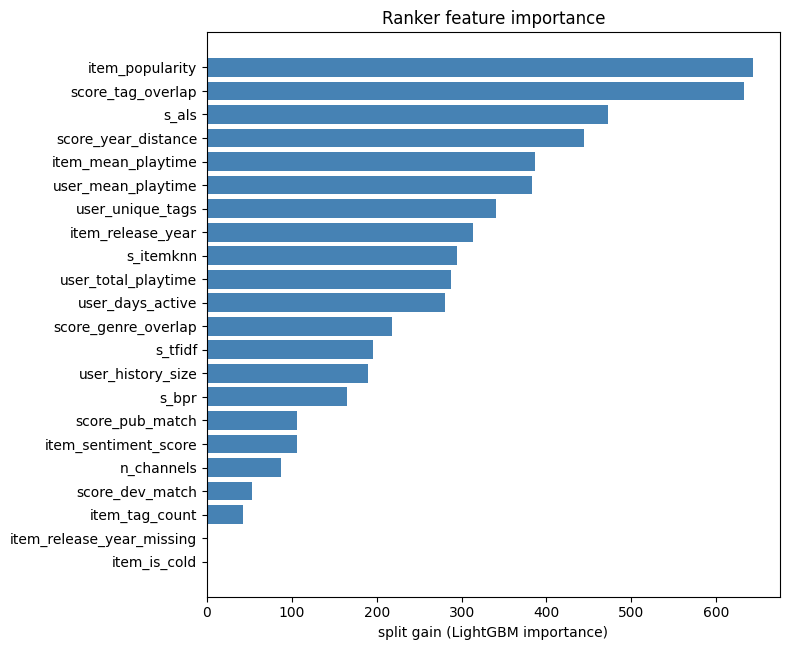

In [60]:
fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(importance))))
ax.barh(importance["feature"], importance["importance"], color="steelblue")
ax.set_xlabel("split gain (LightGBM importance)")
ax.set_title("Ranker feature importance")
plt.tight_layout()
plt.show()

In [61]:
importance[::-1].reset_index(drop=True)

,feature,importance
0,item_popularity,643
1,score_tag_overlap,633
2,s_als,472
3,score_year_distance,444
4,item_mean_playtime,387
5,user_mean_playtime,383
6,user_unique_tags,341
7,item_release_year,313
8,s_itemknn,294
9,user_total_playtime,288


In [62]:
val_pool["score_rank"] = ranker.predict(val_pool[FEATURE_COLS].values)
val_pool["rank_position"] = val_pool.groupby("user_id")["score_rank"].rank(method="first", ascending=False)
top_predictions = val_pool[val_pool["rank_position"] <= FINAL_TOP].sort_values(["user_id", "rank_position"])

recall_scores, ndcg_scores = [], []
for user_id, user_group in top_predictions.groupby("user_id"):
    predicted_items = user_group.sort_values("rank_position")["item_id"].tolist()
    ground_truth_items = val_truth_dict.get(user_id, set())
    recall_scores.append(_recall_at_k(predicted_items, ground_truth_items, EVAL_K))
    ndcg_scores.append(_ndcg_at_k(predicted_items, ground_truth_items, EVAL_K))

mean_recall = float(np.mean(recall_scores))
mean_ndcg = float(np.mean(ndcg_scores))
mean_score = 0.5 * (mean_recall + mean_ndcg)

print(f"  Recall@10 : {mean_recall:.4f}")
print(f"  NDCG@10   : {mean_ndcg:.4f}")
print(f"  Mean      : {mean_score:.4f}   ")

  Recall@10 : 0.1069
  NDCG@10   : 0.0998
  Mean      : 0.1034   


In [63]:
def recall_at(pool_df, k_per_user_col=None, k=None):
    # helper function that measures what fraction if each user held out games apaear in the pooldf 
    if k_per_user_col is not None: # trim pool when rank passed
        pool_df = pool_df.copy()
        pool_df["_r"] = pool_df.groupby("user_id")[k_per_user_col].rank(method="first", ascending=False) # within each user assign rank 1 to the highest scored row
        pool_df = pool_df[pool_df["_r"] <= k] # only top k rows per user
    by_user = pool_df.groupby("user_id")["item_id"].apply(set)

    return float(np.mean([len(truth & by_user.get(uid, set())) / len(truth) for uid, truth in val_truth_dict.items()])) # for each evaluation user get intersection of held out ames and whats in the pool!


In [64]:
stage_breakdown = pd.DataFrame({
    "stage":  ["Retrieval pool", f"After ranker (top-{FINAL_TOP})"],
    "recall": [recall_at(val_pool), recall_at(val_pool, "score_rank", FINAL_TOP)],
    "avg pool size": [val_pool.groupby("user_id").size().mean(), FINAL_TOP],
})
display(stage_breakdown)

,stage,recall,avg pool size
0,Retrieval pool,0.374022,360.1037
1,After ranker (top-10),0.106910,10.0000


# Submission Setupz



In [65]:
test_user_ids = test_users["user_id"].tolist()
test_histories = train.groupby("user_id")["item_id"].apply(list).to_dict()

missing = [u for u in test_user_ids if u not in test_histories]
if missing:
    print(f"{len(missing)} test users have no history in train.csv")
test_histories = {u: test_histories.get(u, []) for u in test_user_ids}

print(f"Building candidate pool for {len(test_histories):,} test users")
test_pool = build_candidate_pool(test_histories, als_full, bpr_full, itemknn_full, channel_budgets=CEM_BUDGETS)

Building candidate pool for 10,000 test users
  built pool for 1,000 / 10,000 users
  built pool for 2,000 / 10,000 users
  built pool for 3,000 / 10,000 users
  built pool for 4,000 / 10,000 users
  built pool for 5,000 / 10,000 users
  built pool for 6,000 / 10,000 users
  built pool for 7,000 / 10,000 users
  built pool for 8,000 / 10,000 users
  built pool for 9,000 / 10,000 users
  built pool for 10,000 / 10,000 users


In [66]:
# feature engineering for the test POOL!
user_feats_full = compute_user_features(train)
item_feats_full = compute_item_features(train)
test_pool = attach_interaction_features(test_pool, test_histories)
test_pool = test_pool.merge(user_feats_full, on="user_id", how="left")
test_pool = test_pool.merge(item_feats_full, on="item_id", how="left")

In [67]:
test_pool["score_rank"] = ranker.predict(test_pool[FEATURE_COLS].values)
test_pool["final_rank"] = test_pool.groupby("user_id")["score_rank"].rank(method="first", ascending=False)
test_topk = test_pool[test_pool["final_rank"] <= FINAL_TOP].sort_values(["user_id", "final_rank"])

In [68]:
# pivot wide into the submission shape
test_topk["rank_col"] = "rank_" + test_topk["final_rank"].astype(int).astype(str)
submission = (
    test_topk.pivot(index="user_id", columns="rank_col", values="item_id")
    .reindex(columns=[f"rank_{i}" for i in range(1, FINAL_TOP + 1)])
    .reset_index()
)

In [69]:
# safety
submission = submission.set_index("user_id").reindex(test_user_ids).reset_index()


In [70]:
submission.to_csv("submission.csv", index=False)


## Validate Submission


In [71]:
validate_submission("submission.csv",
                    DATA_DIR / "test_users.csv",
                    DATA_DIR / "item_metadata.csv")

Submission OK: 10000 users x 10 items.
